In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [2]:
cropped_dir = Path("../data/processed/cropped_products")

sample_path = next(
    (cropped_dir / "aqua").glob("*.jpg")
)

image = cv2.imread(str(sample_path))

print("Image path:", sample_path)
print("Image shape:", image.shape)

Image path: ..\data\processed\cropped_products\aqua\aqua (1)_object_1.jpg
Image shape: (234, 86, 3)


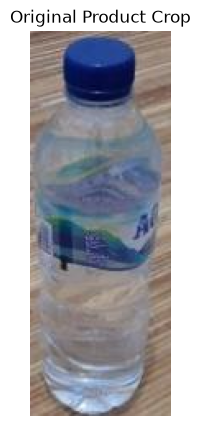

In [3]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Product Crop")
plt.show()

In [4]:
resized = cv2.resize(
    image_rgb,
    (224, 224),
    interpolation=cv2.INTER_AREA
)

print("Original shape:", image_rgb.shape)
print("Resized shape:", resized.shape)

Original shape: (234, 86, 3)
Resized shape: (224, 224, 3)


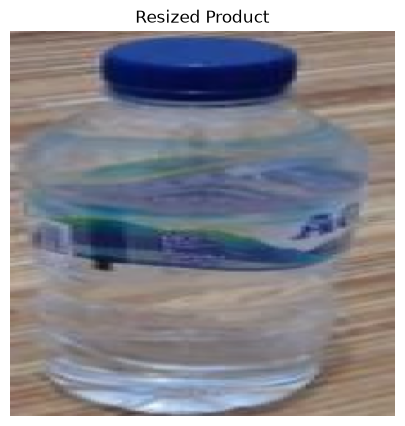

In [5]:
plt.figure(figsize=(5, 5))
plt.imshow(resized)
plt.axis("off")
plt.title("Resized Product")
plt.show()

In [6]:
blurred = cv2.GaussianBlur(
    resized,
    (3, 3),
    0
)

print("Blurred image shape:", blurred.shape)

Blurred image shape: (224, 224, 3)


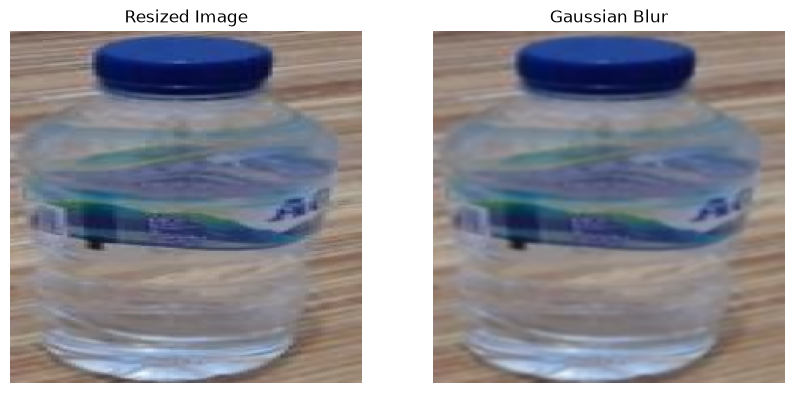

In [7]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(resized)
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred)
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

In [8]:
# Convert RGB image to LAB color space
lab = cv2.cvtColor(
    blurred,
    cv2.COLOR_RGB2LAB
)

# Create CLAHE object
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Apply CLAHE only to the L (lightness) channel
lab[:, :, 0] = clahe.apply(lab[:, :, 0])

# Convert back to RGB
enhanced = cv2.cvtColor(
    lab,
    cv2.COLOR_LAB2RGB
)

print("Enhanced image shape:", enhanced.shape)

Enhanced image shape: (224, 224, 3)


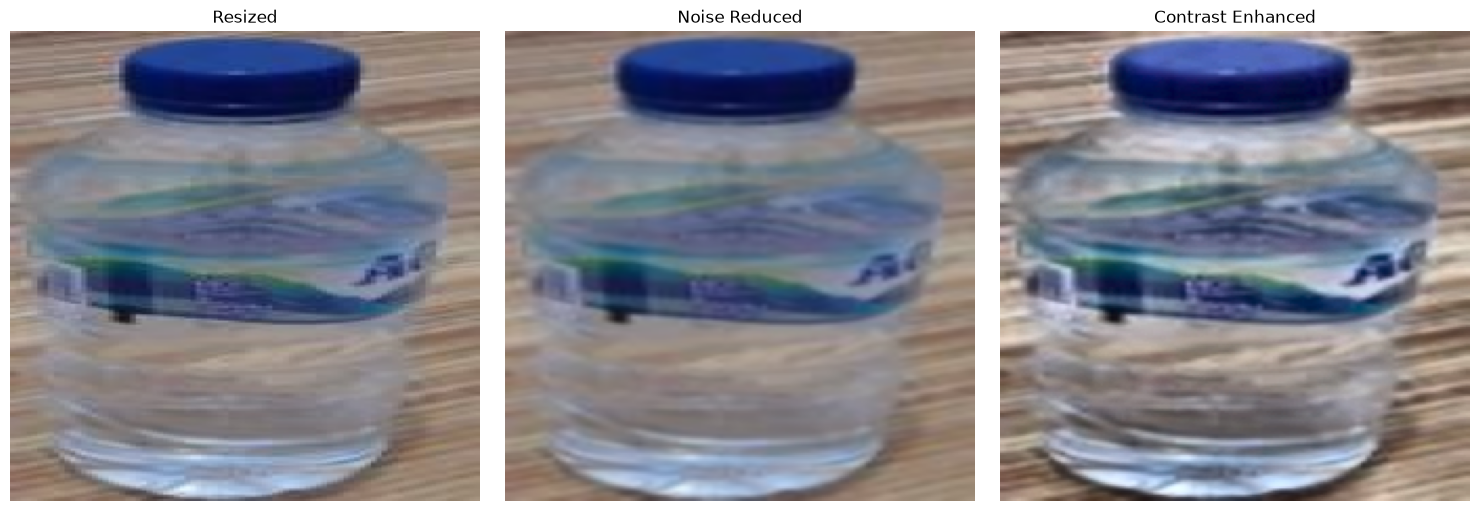

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(resized)
plt.title("Resized")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred)
plt.title("Noise Reduced")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(enhanced)
plt.title("Contrast Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
normalized = enhanced.astype(np.float32) / 255.0

print("Normalized shape:", normalized.shape)
print("Minimum pixel value:", normalized.min())
print("Maximum pixel value:", normalized.max())

Normalized shape: (224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


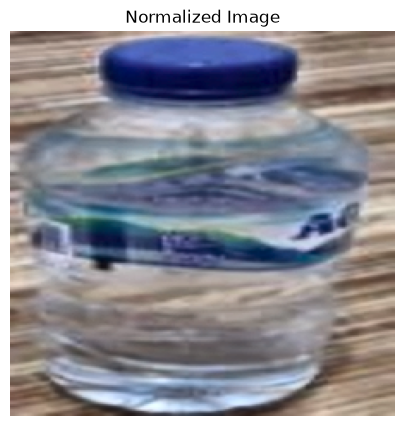

In [11]:
plt.figure(figsize=(5, 5))

plt.imshow(normalized)
plt.title("Normalized Image")
plt.axis("off")

plt.show()

In [12]:
print("Data type:", normalized.dtype)
print("Shape:", normalized.shape)
print("Minimum:", normalized.min())
print("Maximum:", normalized.max())

Data type: float32
Shape: (224, 224, 3)
Minimum: 0.0
Maximum: 1.0


In [13]:
processed_preview = (
    normalized * 255
).astype(np.uint8)

preview_path = cropped_dir / "aqua" / "aqua_preprocessed_preview.jpg"

cv2.imwrite(
    str(preview_path),
    cv2.cvtColor(processed_preview, cv2.COLOR_RGB2BGR)
)

print("Saved:", preview_path)

Saved: ..\data\processed\cropped_products\aqua\aqua_preprocessed_preview.jpg


In [14]:
print(preview_path.exists())

True


In [16]:
classes = [
    "aqua",
    "chitato",
    "indomie",
    "pepsodent",
    "shampoo",
    "tissue"
]

print(classes)

['aqua', 'chitato', 'indomie', 'pepsodent', 'shampoo', 'tissue']


In [17]:
from pathlib import Path

classification_dir = Path("../data/processed/classification")

splits = ["train", "val", "test"]

for split in splits:
    for class_name in classes:
        (classification_dir / split / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

print("Classification dataset folders created.")

Classification dataset folders created.


In [18]:
from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image

classes = [
    "aqua",
    "chitato",
    "indomie",
    "pepsodent",
    "shampoo",
    "tissue"
]

classification_dir = Path("../data/processed/classification")

# Source folders
sources = {
    "train": {
        "image_dir": Path("../data/processed/yolo/images/train"),
        "xml_dir": Path("../data/processed/yolo/labels/train")
    },
    "val": {
        "image_dir": Path("../data/processed/yolo/images/val"),
        "xml_dir": Path("../data/processed/yolo/labels/val")
    },
    "test": {
        "image_dir": Path("../data/processed/yolo/images/test"),
        "xml_dir": Path("../data/processed/yolo/labels/test")
    }
}

for split, paths in sources.items():

    image_dir = paths["image_dir"]
    xml_dir = paths["xml_dir"]

    xml_files = list(xml_dir.glob("*.xml"))

    crop_count = 0

    for xml_file in xml_files:

        image_file = image_dir / f"{xml_file.stem}.jpg"

        if not image_file.exists():
            print(f"Image not found: {image_file.name}")
            continue

        tree = ET.parse(xml_file)
        root = tree.getroot()

        image = Image.open(image_file).convert("RGB")

        for object_index, obj in enumerate(root.findall("object")):

            class_name = obj.find("name").text.strip()

            bbox = obj.find("bndbox")

            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)

            crop = image.crop(
                (xmin, ymin, xmax, ymax)
            )

            output_dir = classification_dir / split / class_name
            output_dir.mkdir(
                parents=True,
                exist_ok=True
            )

            crop_filename = (
                f"{xml_file.stem}_object_{object_index + 1}.jpg"
            )

            crop.save(output_dir / crop_filename)

            crop_count += 1

    print(f"{split}: {crop_count} crops created")

train: 465 crops created
val: 114 crops created
test: 216 crops created


In [19]:
from pathlib import Path

classification_dir = Path("../data/processed/classification")

for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    total = 0

    for class_name in classes:

        class_dir = classification_dir / split / class_name

        count = len(list(class_dir.glob("*.jpg")))

        print(f"{class_name:10s}: {count}")

        total += count

    print(f"Total      : {total}")


TRAIN
aqua      : 77
chitato   : 70
indomie   : 77
pepsodent : 81
shampoo   : 81
tissue    : 79
Total      : 465

VAL
aqua      : 20
chitato   : 27
indomie   : 18
pepsodent : 16
shampoo   : 15
tissue    : 18
Total      : 114

TEST
aqua      : 36
chitato   : 36
indomie   : 38
pepsodent : 36
shampoo   : 35
tissue    : 35
Total      : 216


In [20]:
from pathlib import Path

preprocessed_dir = Path(
    "../data/processed/classification_preprocessed"
)

for split in ["train", "val", "test"]:
    for class_name in classes:
        (
            preprocessed_dir / split / class_name
        ).mkdir(
            parents=True,
            exist_ok=True
        )

print("Preprocessing folders created.")

Preprocessing folders created.


In [21]:
import cv2
import numpy as np

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [22]:
def preprocess_image(image_path):

    # Read image
    image = cv2.imread(str(image_path))

    # Convert BGR → RGB
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Resize
    resized = cv2.resize(
        image_rgb,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    # Gaussian Blur
    blurred = cv2.GaussianBlur(
        resized,
        (3, 3),
        0
    )

    # Convert RGB → LAB
    lab = cv2.cvtColor(
        blurred,
        cv2.COLOR_RGB2LAB
    )

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    lab[:, :, 0] = clahe.apply(
        lab[:, :, 0]
    )

    # LAB → RGB
    enhanced = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced

In [23]:
sample_image = next(
    (classification_dir / "train" / "aqua").glob("*.jpg")
)

processed_sample = preprocess_image(
    sample_image
)

print("Original:", cv2.imread(str(sample_image)).shape)
print("Processed:", processed_sample.shape)
print("Data type:", processed_sample.dtype)

Original: (234, 86, 3)
Processed: (224, 224, 3)
Data type: uint8


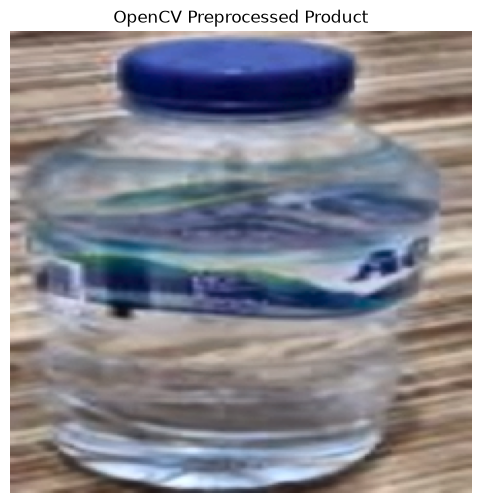

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.imshow(processed_sample)

plt.axis("off")
plt.title("OpenCV Preprocessed Product")

plt.show()

In [26]:
processed_count = 0
skipped_count = 0

for split in ["train", "val", "test"]:

    source_split_dir = classification_dir / split
    output_split_dir = preprocessed_dir / split

    for class_name in classes:

        source_class_dir = source_split_dir / class_name
        output_class_dir = output_split_dir / class_name

        image_files = list(source_class_dir.glob("*.jpg"))

        for image_path in image_files:

            try:
                # OpenCV preprocessing
                processed_image = preprocess_image(
                    image_path
                )

                # Output path
                output_path = (
                    output_class_dir /
                    image_path.name
                )

                # RGB → BGR before saving
                processed_bgr = cv2.cvtColor(
                    processed_image,
                    cv2.COLOR_RGB2BGR
                )

                # Save processed image
                cv2.imwrite(
                    str(output_path),
                    processed_bgr
                )

                processed_count += 1

            except Exception as e:
                print(
                    f"Error processing {image_path}: {e}"
                )
                skipped_count += 1

        print(
            f"{split}/{class_name}: "
            f"{len(image_files)} images processed"
        )

print("\nPreprocessing completed.")
print("Images processed:", processed_count)
print("Images skipped:", skipped_count)

train/aqua: 77 images processed
train/chitato: 70 images processed
train/indomie: 77 images processed
train/pepsodent: 81 images processed
train/shampoo: 81 images processed
train/tissue: 79 images processed
val/aqua: 20 images processed
val/chitato: 27 images processed
val/indomie: 18 images processed
val/pepsodent: 16 images processed
val/shampoo: 15 images processed
val/tissue: 18 images processed
test/aqua: 36 images processed
test/chitato: 36 images processed
test/indomie: 38 images processed
test/pepsodent: 36 images processed
test/shampoo: 35 images processed
test/tissue: 35 images processed

Preprocessing completed.
Images processed: 795
Images skipped: 0


In [27]:
from PIL import Image

wrong_size = []
total_checked = 0

for split in ["train", "val", "test"]:

    for class_name in classes:

        image_dir = (
            preprocessed_dir /
            split /
            class_name
        )

        for image_path in image_dir.glob("*.jpg"):

            with Image.open(image_path) as img:

                total_checked += 1

                if img.size != (224, 224):
                    wrong_size.append(
                        (image_path.name, img.size)
                    )

print("Total images checked:", total_checked)
print("Wrong-size images:", len(wrong_size))

if wrong_size:
    print(wrong_size[:10])

Total images checked: 795
Wrong-size images: 0


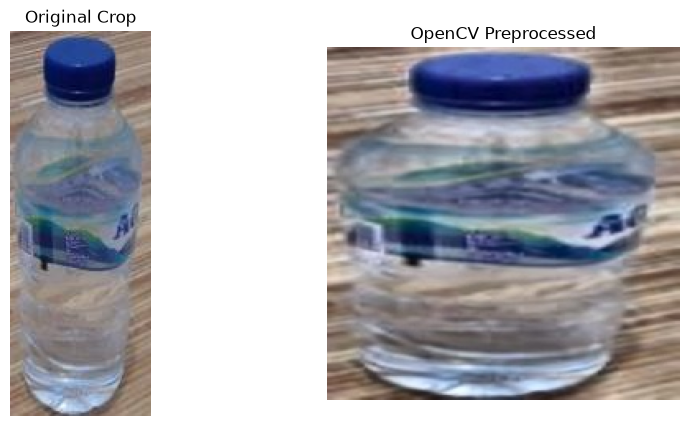

In [28]:
import matplotlib.pyplot as plt
import cv2

# Select one original image
original_path = next(
    (classification_dir / "train" / "aqua").glob("*.jpg")
)

# Corresponding processed image
processed_path = (
    preprocessed_dir /
    "train" /
    "aqua" /
    original_path.name
)

# Read images
original = cv2.imread(str(original_path))
original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

processed = cv2.imread(str(processed_path))
processed = cv2.cvtColor(
    processed,
    cv2.COLOR_BGR2RGB
)

# Display
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.axis("off")
plt.title("Original Crop")

plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.axis("off")
plt.title("OpenCV Preprocessed")

plt.show()